<a href="https://colab.research.google.com/github/lilara4/Sentiment-Analysis/blob/main/Clean_SuperStore_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Sample Superstore.csv", encoding='latin-1')
print(df.head(20))

    Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0        1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1        2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2        3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3        4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4        5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
5        6  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
6        7  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
7        8  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
8        9  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
9       10  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
10      11  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
11      12  CA-2014-115812    6/9/2014   6/14/2014  Standard Class   
12      13  CA-2017-114412   4/15/2017   4/20/2017  Standard Class   
13      14  CA-2016-

>> Summary Statistics 
              Sales     Quantity     Discount       Profit
count   9994.000000  9994.000000  9994.000000  9994.000000
mean     229.858001     3.789574     0.156203    28.656896
std      623.245101     2.225110     0.206452   234.260108
min        0.444000     1.000000     0.000000 -6599.978000
25%       17.280000     2.000000     0.000000     1.728750
50%       54.490000     3.000000     0.200000     8.666500
75%      209.940000     5.000000     0.200000    29.364000
max    22638.480000    14.000000     0.800000  8399.976000


>> Correlation Matrix 
             Sales  Quantity  Discount    Profit
Sales     1.000000  0.200795 -0.028190  0.479064
Quantity  0.200795  1.000000  0.008623  0.066253
Discount -0.028190  0.008623  1.000000 -0.219487
Profit    0.479064  0.066253 -0.219487  1.000000


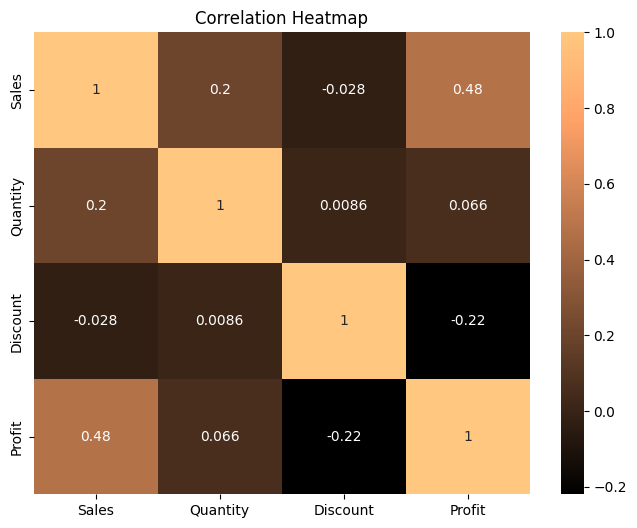

>> Key Metrics

Missing Values per Column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Value Counts for Order ID:
Order ID
CA-2017-100111    14
CA-2017-157987    12
CA-2016-165330    11
US-2016-108504    11
US-2015-126977    10
                  ..
CA-2014-110422     1
CA-2016-125794     1
CA-2017-163566     1
US-2015-151435     1
CA-2016-130225     1
Name: count, Length: 5009, dtype: int64

Value Counts for Ship Mode:
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

Value Counts for Customer ID:
Customer ID
WB-21850    37
MA-17560    34
JL-1583

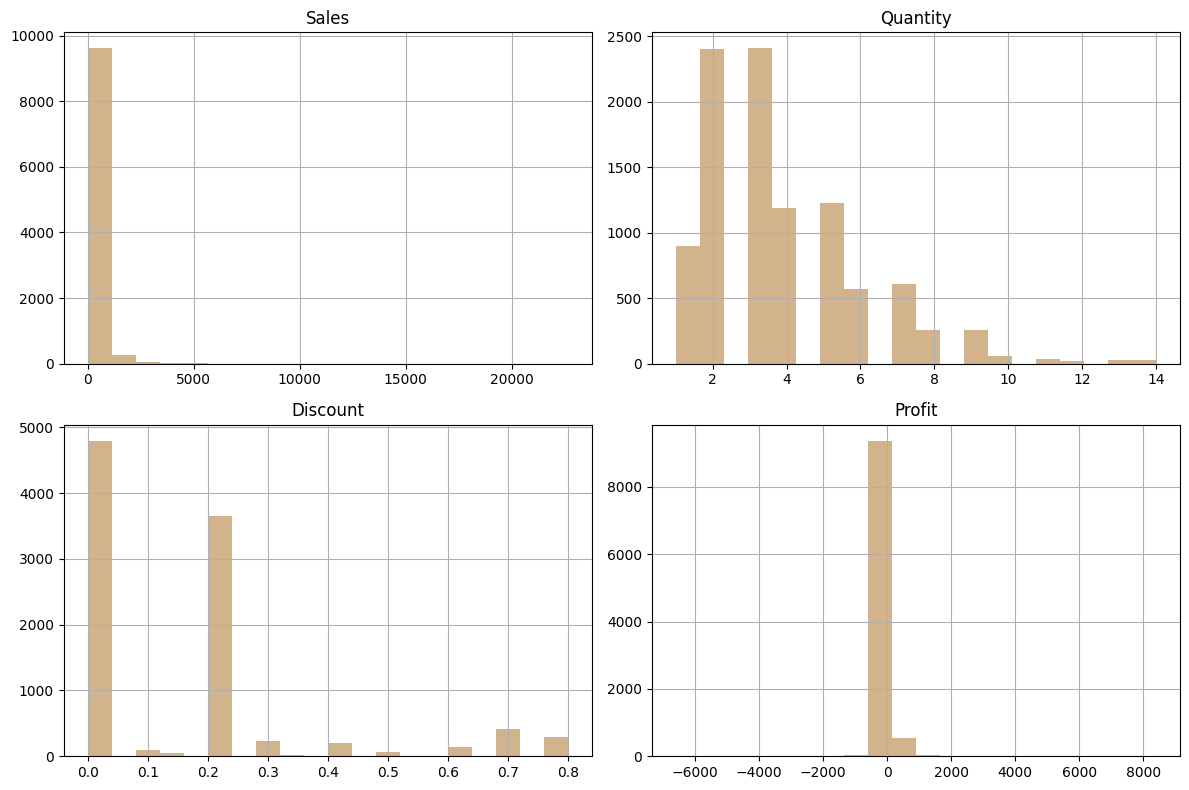

In [ ]:
print(">> Summary Statistics ")
print(df[['Sales', 'Quantity', 'Discount', 'Profit']].describe())
print("\n")

print(">> Correlation Matrix ")
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='copper')
plt.title('Correlation Heatmap')
plt.show()

print(">> Key Metrics")
print("\nMissing Values per Column:")
print(df.isnull().sum())

categorical_cols = ['Order ID', 'Ship Mode', 'Customer ID', 'Customer Name',
                    'Segment', 'Country', 'City', 'State', 'Region',
                    'Product ID', 'Category', 'Sub-Category', 'Product Name']
for col in categorical_cols:
    print(f"\nValue Counts for {col}:")
    print(df[col].value_counts())

numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
df[numeric_cols].hist(figsize=(12,8), bins=20, color='#D2B48C')
plt.tight_layout()
plt.show()

In [ ]:
# Summary of issues
summary = {
    "missing_values": df.isnull().sum(),
    "duplicates": df.duplicated().sum(),
    "data_types": df.dtypes,
    "discount_out_of_range": df[(df['Discount'] < 0) | (df['Discount'] > 1)].shape[0],
    "date_check": (df['Ship Date'] < df['Order Date']).sum()
}

summary

{'missing_values': Row ID           0
 Order ID         0
 Order Date       0
 Ship Date        0
 Ship Mode        0
 Customer ID      0
 Customer Name    0
 Segment          0
 Country          0
 City             0
 State            0
 Postal Code      0
 Region           0
 Product ID       0
 Category         0
 Sub-Category     0
 Product Name     0
 Sales            0
 Quantity         0
 Discount         0
 Profit           0
 dtype: int64,
 'duplicates': np.int64(0),
 'data_types': Row ID             int64
 Order ID          object
 Order Date        object
 Ship Date         object
 Ship Mode         object
 Customer ID       object
 Customer Name     object
 Segment           object
 Country           object
 City              object
 State             object
 Postal Code        int64
 Region            object
 Product ID        object
 Category          object
 Sub-Category      object
 Product Name      object
 Sales            float64
 Quantity           int64
 Discount  

In [ ]:
# Convert Order Date and Ship Date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# Check missing values before cleaning
print("Missing values BEFORE cleaning:")
print(df[['Order Date', 'Ship Date']].isna().sum())
print("\n")

#Fix Ship Date Using Median Shippig Days
valid_dates = df[(df['Ship Date'].notna())&
                 (df['Order Date'].notna())&
                 (df['Ship Date'] >= df['Order Date'] )]

shipping_days = (valid_dates['Ship Date']- valid_dates['Order Date']).dt.days

median_days = shipping_days.median()
print("media shipping days:", median_days)

df.loc[df['Ship Date'] < df['Order Date'] , 'Ship Date'] =df['Order Date']+ pd.Timedelta(days=median_days)
df.loc[df['Ship Date'].isna(),'Ship Date']=df['Order Date']+pd.Timedelta(days=median_days)


# Check missing values after cleaning
print("Missing values AFTER cleaning:")
print(df[['Order Date', 'Ship Date']].isna().sum())
print("\n")

# Data quality validation report
print("Data Quality Report:")
print("-"*40)

# Count logical date errors
errors = (df['Ship Date'] < df['Order Date']).sum()
print(f"Ship Date earlier than Order Date: {errors}")

# Check data types of date columns
print("Date types check:")
print(df[['Order Date', 'Ship Date']].dtypes)

# Display sample of cleaned data
print("\nSample cleaned rows:")
print(df[['Order Date', 'Ship Date']].head(20))

# Save cleaned dataset to CSV file
df.to_csv('results.csv', index=False)


Missing values BEFORE cleaning:
Order Date    0
Ship Date     0
dtype: int64


media shipping days: 4.0
Missing values AFTER cleaning:
Order Date    0
Ship Date     0
dtype: int64


Data Quality Report:
----------------------------------------
Ship Date earlier than Order Date: 0
Date types check:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

Sample cleaned rows:
   Order Date  Ship Date
0  2016-11-08 2016-11-11
1  2016-11-08 2016-11-11
2  2016-06-12 2016-06-16
3  2015-10-11 2015-10-18
4  2015-10-11 2015-10-18
5  2014-06-09 2014-06-14
6  2014-06-09 2014-06-14
7  2014-06-09 2014-06-14
8  2014-06-09 2014-06-14
9  2014-06-09 2014-06-14
10 2014-06-09 2014-06-14
11 2014-06-09 2014-06-14
12 2017-04-15 2017-04-20
13 2016-12-05 2016-12-10
14 2015-11-22 2015-11-26
15 2015-11-22 2015-11-26
16 2014-11-11 2014-11-18
17 2014-05-13 2014-05-15
18 2014-08-27 2014-09-01
19 2014-08-27 2014-09-01


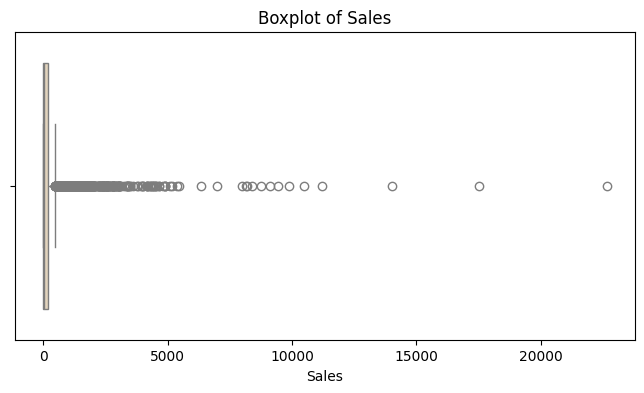

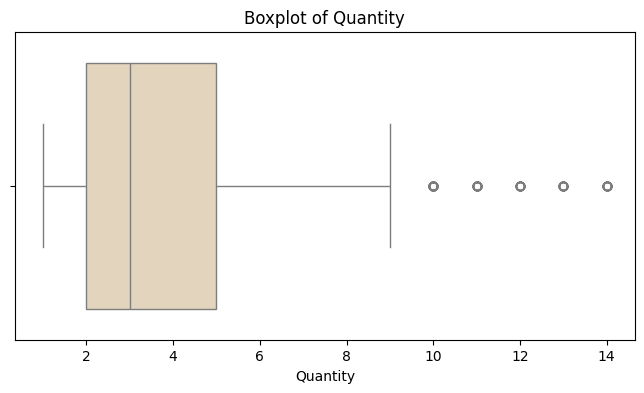

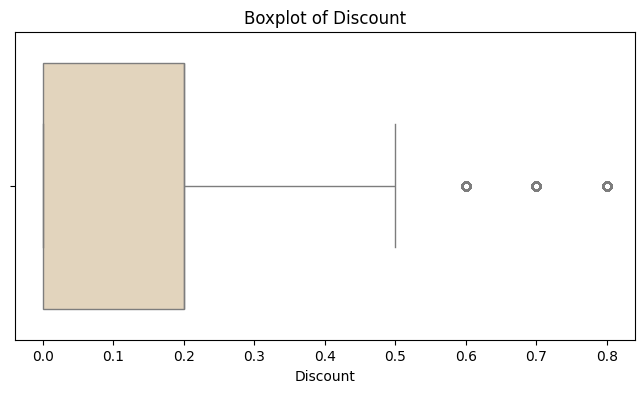

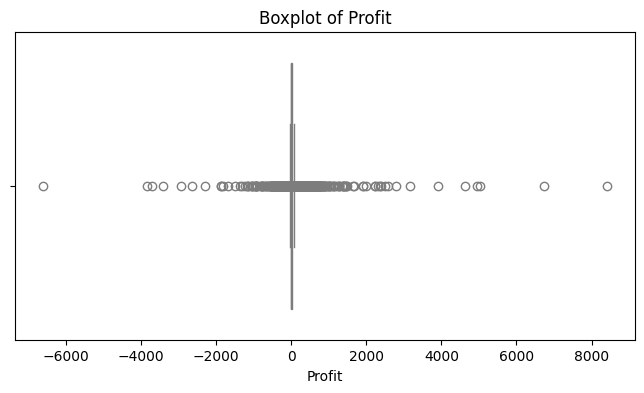

Sales: 1167 outliers, Lower bound = -271.71000000000004, Upper bound = 498.93
Quantity: 170 outliers, Lower bound = -2.5, Upper bound = 9.5
Discount: 856 outliers, Lower bound = -0.30000000000000004, Upper bound = 0.5
Profit: 1881 outliers, Lower bound = -39.724125, Upper bound = 70.816875


In [ ]:
# Select numeric columns for outlier detection
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

# Dictionary to store outlier summary for each column
outliers_summary = {}

# Loop through each numeric column
for col in numeric_cols:

    # Calculate Q1, Q3, and IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Define lower and upper bounds using IQR method
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Store outlier information
    outliers_summary[col] = {
        'count': outliers.shape[0],
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }

    # Plot boxplot to visualize outliers
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], color ='#E8D5B7')
    plt.title(f'Boxplot of {col}')
    plt.show()

# Print summary of detected outliers
for col, info in outliers_summary.items():
    print(f"{col}: {info['count']} outliers, "
          f"Lower bound = {info['lower_bound']}, "
          f"Upper bound = {info['upper_bound']}")

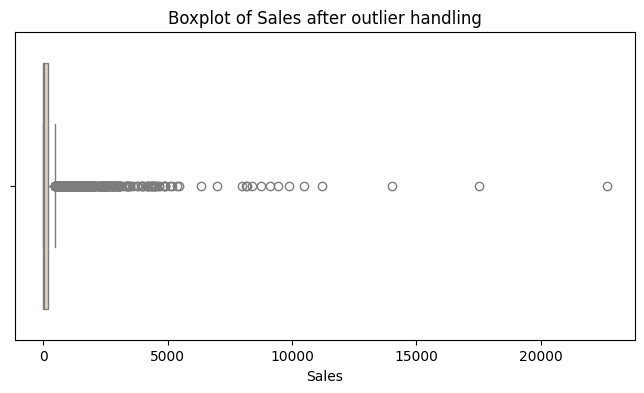

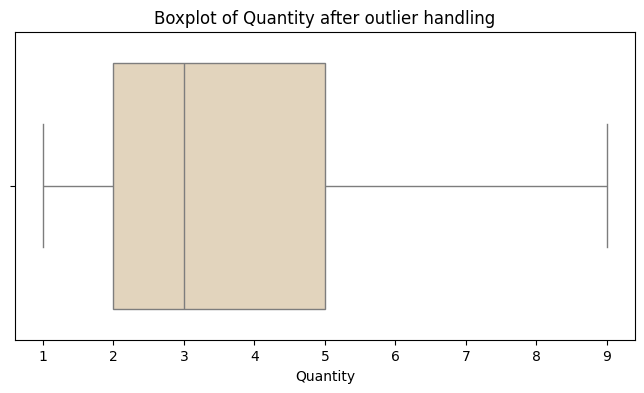

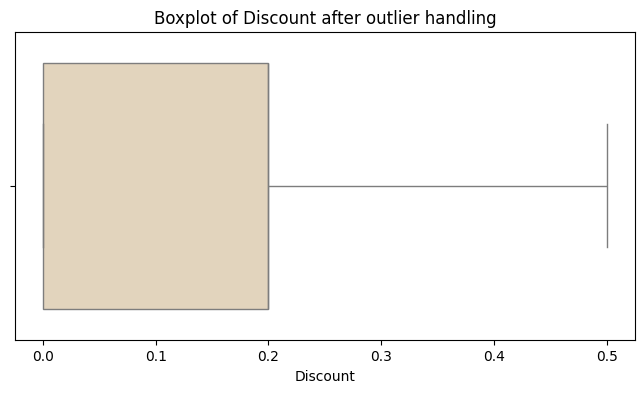

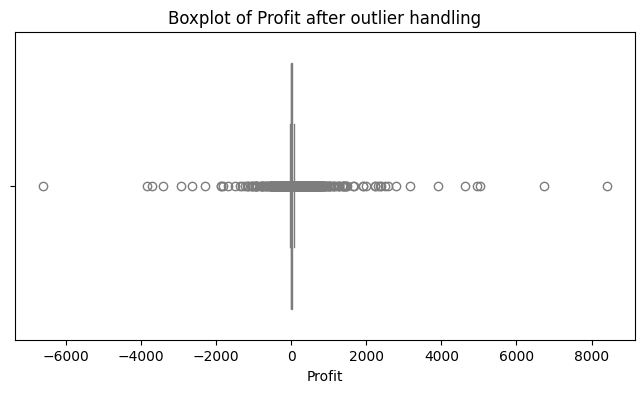

Sales: min = 0.444, max = 22638.48
Quantity: min = 1, max = 9
Discount: min = 0.0, max = 0.5
Profit: min = -6599.978, max = 8399.976


In [ ]:
# Numeric columns to handle outliers
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

# Dictionary to store lower and upper bounds
bounds = {}

# Calculate IQR bounds for each numeric column
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    bounds[col] = (lower_bound, upper_bound)

# Handle outliers by clipping values to acceptable ranges


# Quantity should be at least 1
df['Quantity'] = df['Quantity'].clip(lower=1, upper=int(bounds['Quantity'][1]))

# Discount is limited to a reasonable range (0 to 50%)
df['Discount'] = df['Discount'].clip(lower=0, upper=0.5)


# Visualize data after outlier handling
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col],color ='#E8D5B7')
    plt.title(f'Boxplot of {col} after outlier handling')
    plt.show()

# Print min and max values after cleaning
for col in numeric_cols:
    print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")

# Save the cleaned dataset
df.to_csv('Samplemy_Superstore_clean_simple.csv', index=False)
